# Hierarchical clustering
- used for Exploatory data analysis

In [90]:
# Hierarchical Clustering on Iris Dataset

from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler

# sckit-learn doesn’t give a dendrogram by default (but you can approximate one from the linkage).
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import matplotlib.pyplot as plt

In [91]:
# 1. (OPTIONAL)Load the Iris dataset suing scikit learn 
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to DataFrame for clarity
df = pd.DataFrame(X, columns=feature_names)
df['actual_label'] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   actual_label  
0             0  
1             0  
2             0  
3             0  
4             0  


In [92]:
df = pd.read_csv("data_iris_without_labels.csv")
print(df.sample(10))

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
108           6.7          2.5           5.8          1.8
72            6.3          2.5           4.9          1.5
123           6.3          2.7           4.9          1.8
29            4.7          3.2           1.6          0.2
81            5.5          2.4           3.7          1.0
80            5.5          2.4           3.8          1.1
115           6.4          3.2           5.3          2.3
132           6.4          2.8           5.6          2.2
84            5.4          3.0           4.5          1.5


In [93]:
# 2. Standardize the data (VERY IMPORTANT for HC). TODO Remove the column actual label
scaler = StandardScaler()

# scaler.fit(df)
# X_scaled = scaler.transform(df)

X_scaled = scaler.fit_transform(df)

# print first 10 values of scaled data
print(X_scaled[:10])

[[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.02184904  1.26346019 -1.3412724  -1.31297673]
 [-0.53717756  1.95766909 -1.17067529 -1.05003079]
 [-1.50652052  0.80065426 -1.3412724  -1.18150376]
 [-1.02184904  0.80065426 -1.2844067  -1.31297673]
 [-1.74885626 -0.35636057 -1.3412724  -1.31297673]
 [-1.14301691  0.10644536 -1.2844067  -1.4444497 ]]


In [94]:
# Optional: Choose palette and font scale

plt.style.use("dark_background")  
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["gold"])
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "lines.linewidth": 2.5
})

plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

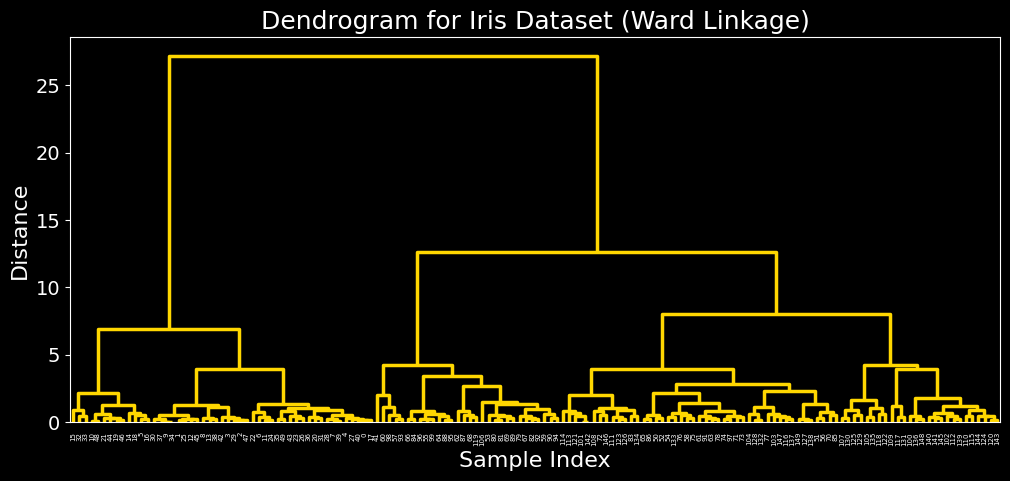

In [95]:

# 3. Perform hierarchical clustering (Ward linkage)
Z = linkage(X_scaled, method='ward')

# 4. Plot dendrogram
plt.figure(figsize=(12, 5))
plt.title("Dendrogram for Iris Dataset (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
dendrogram(Z)
plt.show()

# Look for long vertical lines not crossed by any horizontal line.
# The number of vertical branches below the cut is the number of clusters.
# For the Iris dataset, you typically see 3 large branches → 3 natural clusters.

In [96]:
# 4. Predict clusters (k = 3)
clusters = fcluster(Z, t=3, criterion='maxclust')
df['predicted_cluster'] = clusters
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width  predicted_cluster
0           5.1          3.5           1.4          0.2                  1
1           4.9          3.0           1.4          0.2                  1
2           4.7          3.2           1.3          0.2                  1
3           4.6          3.1           1.5          0.2                  1
4           5.0          3.6           1.4          0.2                  1


In [97]:
print(df["predicted_cluster"].nunique())
print(df["predicted_cluster"].unique())
print(df["predicted_cluster"].value_counts())


3
[1 2 3]
predicted_cluster
3    71
1    49
2    30
Name: count, dtype: int64


In [98]:
# 5. Scatter plots: Actual vs Predicted

In [99]:
df_actual = pd.read_csv("data_iris_with_labels.csv")
print(df_actual.sample(10))

     sepal_length  sepal_width  petal_length  petal_width     species
54            6.5          2.8           4.6          1.5  versicolor
36            5.5          3.5           1.3          0.2      setosa
140           6.7          3.1           5.6          2.4   virginica
147           6.5          3.0           5.2          2.0   virginica
35            5.0          3.2           1.2          0.2      setosa
145           6.7          3.0           5.2          2.3   virginica
68            6.2          2.2           4.5          1.5  versicolor
122           7.7          2.8           6.7          2.0   virginica
105           7.6          3.0           6.6          2.1   virginica
129           7.2          3.0           5.8          1.6   virginica


In [100]:
df['actual_species'] = df_actual['species']
print(df.sample(10))

     sepal_length  sepal_width  petal_length  petal_width  predicted_cluster  \
122           7.7          2.8           6.7          2.0                  3   
61            5.9          3.0           4.2          1.5                  3   
62            6.0          2.2           4.0          1.0                  2   
58            6.6          2.9           4.6          1.3                  3   
16            5.4          3.9           1.3          0.4                  1   
91            6.1          3.0           4.6          1.4                  3   
140           6.7          3.1           5.6          2.4                  3   
149           5.9          3.0           5.1          1.8                  3   
130           7.4          2.8           6.1          1.9                  3   
70            5.9          3.2           4.8          1.8                  3   

    actual_species  
122      virginica  
61      versicolor  
62      versicolor  
58      versicolor  
16          se

In [101]:
# Encode actual labels
label_map = {
    'setosa': 1,
    'versicolor': 2,
    'virginica': 3
}

df['species_label'] = df['actual_species'].map(label_map)
print(df.sample(10))

     sepal_length  sepal_width  petal_length  petal_width  predicted_cluster  \
30            4.8          3.1           1.6          0.2                  1   
36            5.5          3.5           1.3          0.2                  1   
124           6.7          3.3           5.7          2.1                  3   
143           6.8          3.2           5.9          2.3                  3   
19            5.1          3.8           1.5          0.3                  1   
13            4.3          3.0           1.1          0.1                  1   
77            6.7          3.0           5.0          1.7                  3   
132           6.4          2.8           5.6          2.2                  3   
75            6.6          3.0           4.4          1.4                  3   
14            5.8          4.0           1.2          0.2                  1   

    actual_species  species_label  
30          setosa              1  
36          setosa              1  
124      vi

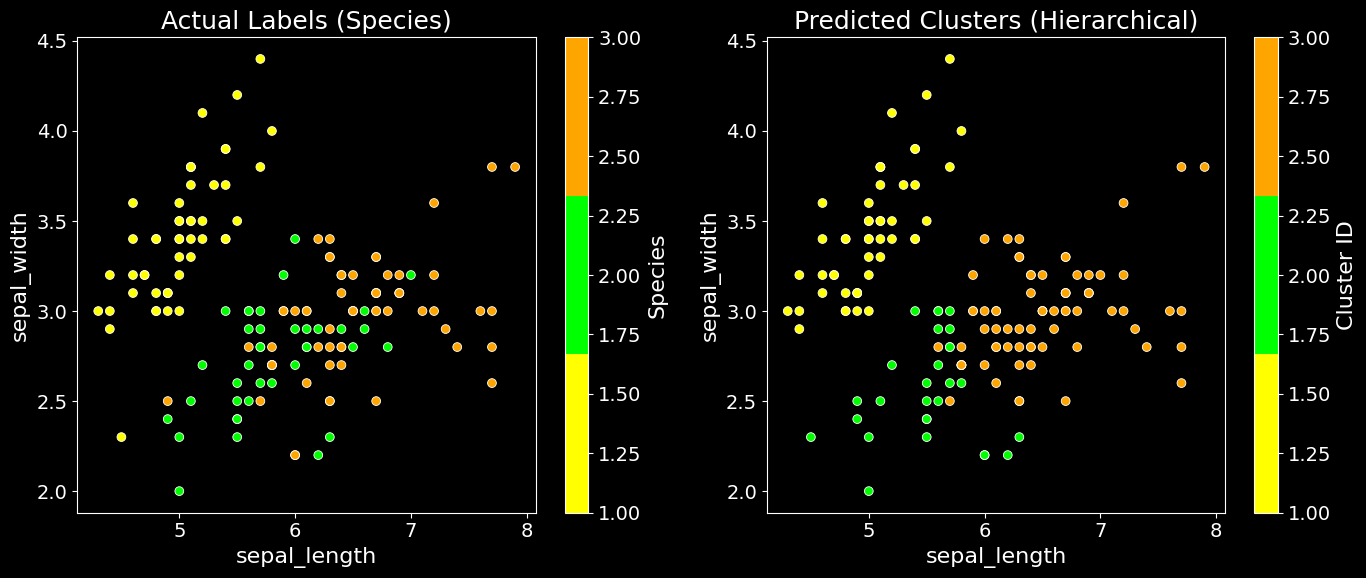

In [119]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["yellow", "lime", "orange"])

colx = "sepal_length"
coly = "sepal_width"

x = df[colx]
y = df[coly]
plt.figure(figsize=(14, 6))
# ----- LEFT PLOT (Actual Labels) -----
plt.subplot(1, 2, 1)
sc1 = plt.scatter(
    x, y,
    c=df['species_label'],
    cmap=custom_cmap, #  Set1,   tab10
    s=40,
    edgecolors="white",    
    linewidth=0.6
)
plt.title("Actual Labels (Species)")
plt.xlabel(colx)
plt.ylabel(coly)
plt.colorbar(sc1, label="Species")

# ----- RIGHT PLOT (Predicted Clusters) -----
plt.subplot(1, 2, 2)
sc2 = plt.scatter(
    x, y,
    c=df['predicted_cluster'],
    cmap=custom_cmap, #"Set1",          # cmap= Set1,   tab10, Paired
    s=40,
    edgecolors="white",
    linewidth=0.6
)
plt.title("Predicted Clusters (Hierarchical)")
plt.xlabel(colx)
plt.ylabel(coly)
plt.colorbar(sc2, label="Cluster ID")

plt.tight_layout()
plt.show()


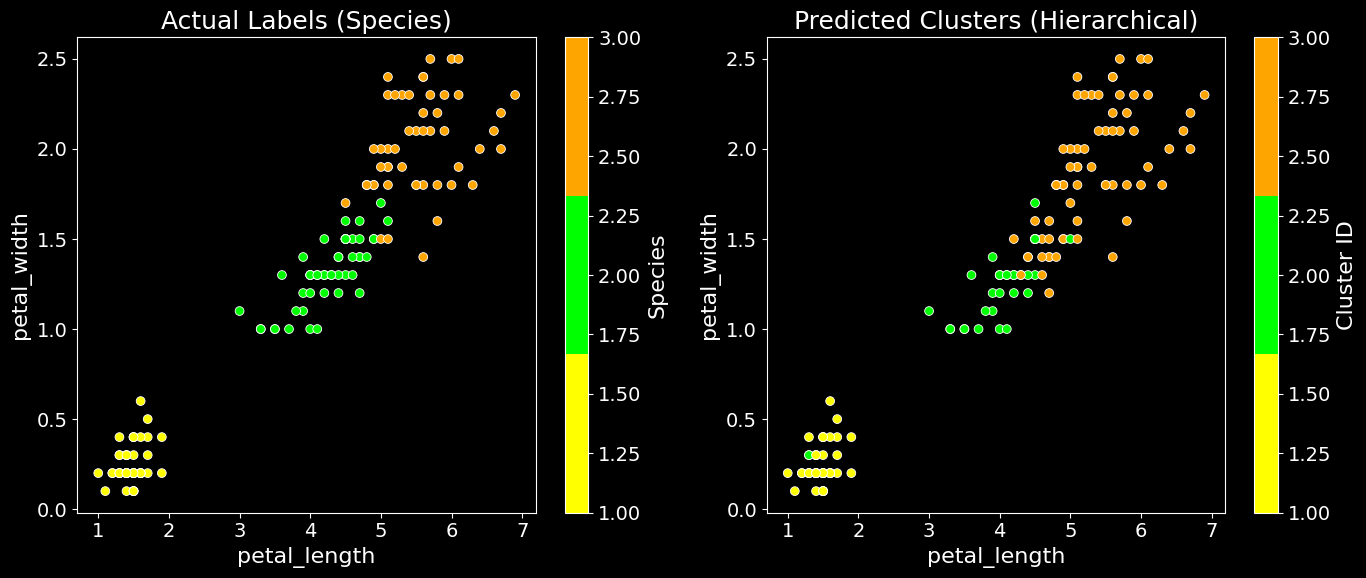

In [123]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["yellow", "lime", "orange"]) # "magenta"])

plt.figure(figsize=(14, 6))

colx = "petal_length"
coly = "petal_width"
x = df[colx]
y = df[coly]

# ----- LEFT PLOT (Actual Labels) -----
plt.subplot(1, 2, 1)
sc1 = plt.scatter(
    x, y,
    c=df['species_label'],
    cmap=custom_cmap, # "Set1",      # cmap= Set1,   tab10
    s=40,
    edgecolors="white",    
    linewidth=0.6
)
plt.title("Actual Labels (Species)")
plt.xlabel(colx)
plt.ylabel(coly)
plt.colorbar(sc1, label="Species")

# ----- RIGHT PLOT (Predicted Clusters) -----
plt.subplot(1, 2, 2)
sc2 = plt.scatter(
    x, y,
    c=df['predicted_cluster'],
    cmap=custom_cmap, # "Set1",          # cmap= Set1,   tab10, Paired
    s=40,
    edgecolors="white",
    linewidth=0.6
)
plt.title("Predicted Clusters (Hierarchical)")
plt.xlabel(colx)
plt.ylabel(coly)
plt.colorbar(sc2, label="Cluster ID")

plt.tight_layout()
plt.show()


# How good is the model ?

In [104]:
# Use Adjusted Rand Index
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['actual_species'], df['predicted_cluster'])

print("ARI:", ari)

ARI: 0.6153229932145449


[[49  1  0]
 [ 0 27 23]
 [ 0  2 48]]
######################


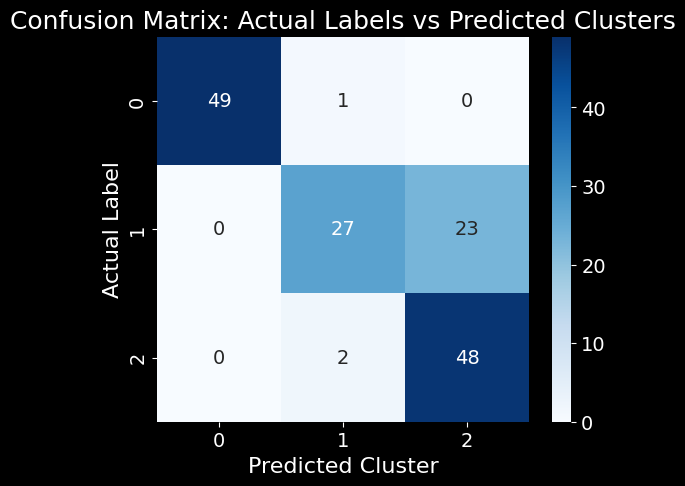

In [105]:
# OPTIONAL: Lets check accuracy, (although this metric does NOT make sense in clustering)

import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(df['species_label'], df['predicted_cluster'])
print(cm)

print("######################")
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True
)

plt.title("Confusion Matrix: Actual Labels vs Predicted Clusters")
plt.xlabel("Predicted Cluster")
plt.ylabel("Actual Label")
plt.show()